**Code Summary**

The Jupyter cell loads the raw *Eurasian Otter* dataset via `DataImporter`, then calls `create_train_test_split_otter` to deterministically build three splits:

1. **Inference** – all footprints from the “Fieldprints Portugal” source.
2. **Test** – every DNA-confirmed footprint from Lower Saxony plus fixed, seed‑controlled samples of individuals from “Own Data Collection” (3♀, 3♂) and “Vetrecova et al.” (2♀, 2♂).
3. **Train** – all remaining individuals.

The train data are assigned fold IDs using `_make_folds` (group‑stratified K‑fold with `NUM_FOLDS = 3`), ensuring footprints from the same individual stay in a single fold. Each split is stored as a Parquet file under `data/splits/eurasian_otter/`.

Finally, `run_summary` computes dataset statistics and saves them (including plots) to `results/data/eurasian_otter_summary.csv` and the corresponding figure directory.



🔄 Starte Otter-Splitting...
🛰️ Inference-Split – 81 Zeilen
↪️ Inference 'dataorigin': ['Fieldprints Portugal']
↪️ Inference 'sex' unique: ['unknown']

🧹 df_clean – 547 Zeilen (ohne Portugal)
🧾 dataorigin: ['Vetrecova et al' 'Own Data Collection' 'Fieldprints Lower Saxony']
🧬 sex: ['f' 'm']
🆔 individual_id: 41

🔬 Erzeuge Test-Split...
✅ Test-Split fertig – 152 Zeilen
👤 Test-Individuals: 14
📊 Test 'dataorigin': dataorigin
Own Data Collection         76
Vetrecova et al             40
Fieldprints Lower Saxony    36
🧬 Test 'sex': sex
f    86
m    66

🧠 Train-Split – 395 Zeilen
👤 Train-Individual IDs: 27
📊 Train 'dataorigin': dataorigin
Own Data Collection    343
Vetrecova et al         52
🧬 Train 'sex': sex
f    220
m    175

🎲 Berechne Fold-Zuordnung...

✅ Fold method used: stratified_group
📊 Fold-Verteilung:
Fold
0    123
1    142
2    130
Name: count, dtype: int64

[DEBUG] compute_summary called for eurasian_otter/inference, df shape = (81, 214)
[DEBUG] ds_label = eurasian_otter Inferen

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:237: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids


[DEBUG] sex = Male, subset shape = (66, 214)
[DEBUG]  n_fp=66, n_ind=7, n_tr=8
[DEBUG]   fp_per_ind summary: mean=9.428571428571429, sd=5.551245493635841
[DEBUG]   tr_per_ind summary: mean=1.2857142857142858, sd=0.45175395145262565
[DEBUG] sex = Unknown, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] Returning summary DataFrame with shape (3, 10)

[DEBUG] compute_summary called for eurasian_otter/train, df shape = (395, 215)
[DEBUG] ds_label = eurasian_otter Train
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['lutra_lutra']
[DEBUG] species_code = lutra lutra
[DEBUG] sex value counts:
sex
Female    220
Male      175
Name: count, dtype: int64
[DEBUG] sex = Female, subset shape = (220, 215)
[DEBUG]  n_fp=220, n_ind=13, n_tr=29
[DEBUG]   fp_per_ind summary: mean=16.923076923076923, sd=7.332347073718446
[DEBUG]   tr_per_ind summary: mean=2.8

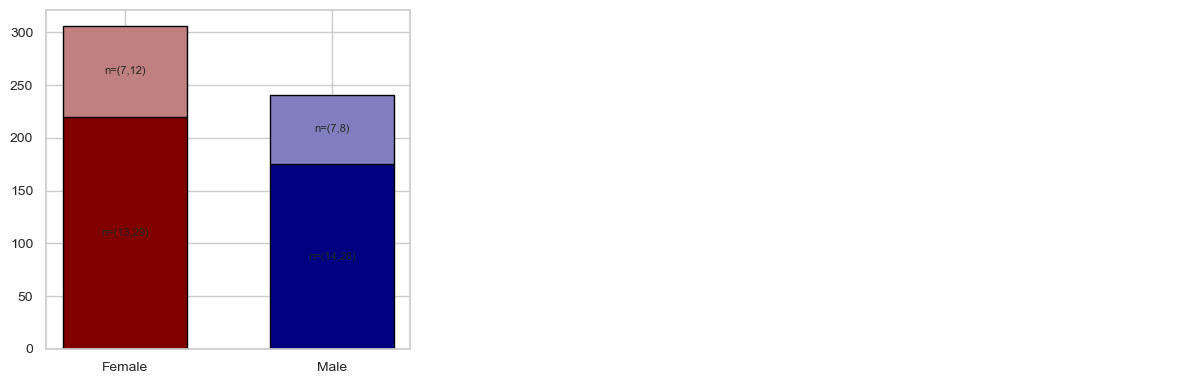

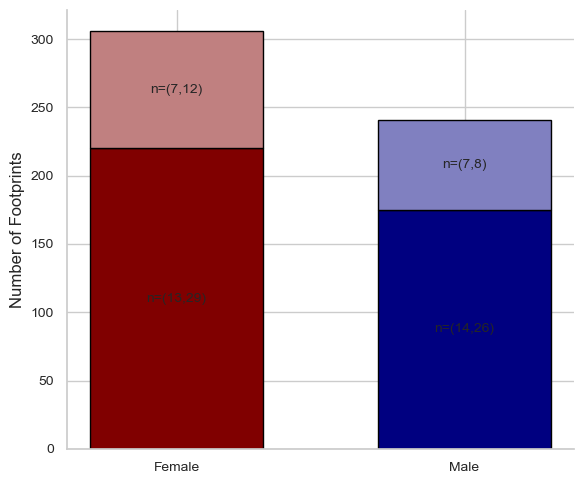

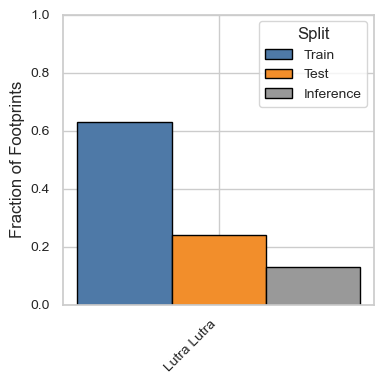

In [1]:
from pathlib import Path

from FIT_python.data_split_and_summary.data_import_wrapper import DataImporter
from FIT_python.data_split_and_summary.split_utils import (
    create_train_test_split_otter,
    _make_folds,
)
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from FIT_python.config import (
    RAW_DIR,
    SPLITS_DIR,
    RESULTS_DATA_DIR,
    DEFAULT_TARGETS,
    GROUP_COL,
    NUM_FOLDS,
)

# --- 1. Load the raw Eurasian otter table
importer = DataImporter(RAW_DIR, target_cols=DEFAULT_TARGETS)
dfs = importer.run()
otter_key = next(k for k in dfs if "otter" in k.lower())
df = dfs[otter_key]

# --- 2. Create deterministic train/test/inference splits
train_df, test_df, inf_df = create_train_test_split_otter(df)

# --- 3. Assign folds for cross‑validation
y_train = train_df["sex"].map({"f": 0, "m": 1})
folds, _ = _make_folds(train_df, y_train, n_splits=NUM_FOLDS, group_col=GROUP_COL)
train_df = train_df.assign(Fold=folds)

# --- 4. Save split files
split_dir = SPLITS_DIR / "eurasian_otter"
split_dir.mkdir(parents=True, exist_ok=True)
train_df.to_parquet(split_dir / "train.parquet", index=False)
test_df.to_parquet(split_dir / "test.parquet", index=False)
inf_df.to_parquet(split_dir / "inference.parquet", index=False)

# --- 5. Generate summary statistics and plots
run_summary(
    split_dir,
    RESULTS_DATA_DIR / "eurasian_otter_summary.csv",
    RESULTS_DATA_DIR / "eurasian_otter_fig",
)


**Otter Data Splitting Summary**

- **Inference split:** 81 rows from *Fieldprints Portugal*, all labeled with unknown sex.
- **Filtered data (`df_clean`):** 547 rows remaining after removing Portugal samples, spanning origins *Vetrecova et al.*, *Own Data Collection*, and *Fieldprints Lower Saxony*. Contains 41 unique individuals (sexes “f” and “m”).
- **Test split:** Created with 152 rows across 14 individuals. Distribution by origin:  
  - Own Data Collection – 76  
  - Vetrecova et al. – 40  
  - Fieldprints Lower Saxony – 36  
  Sex balance: 86 “f” vs. 66 “m”.
- **Train split:** Remaining 395 rows from 27 individuals.  
- A summary step was attempted but skipped because `eurasian_otter_summary.csv` already exists.


# Overview of the Notebook

This notebook performs a step-by-step analysis of Eurasian otter footprint data, from loading and styling through to feature exploration and visualization:

1. **Styling and Configuration**  
   - Import project paths and configuration constants.  
   - Apply a consistent “whitegrid” theme, custom DPI, font sizes, and a sex-specific color palette (`Female`, `Male`, `Unknown`) via `apply_style()`.

2. **Data Loading & Preprocessing**  
   - Read the training split from disk (`train.parquet`).  
   - Standardize the raw `sex` column (`'f'`, `'F'`, `0`, `'m'`, `'M'`, `1`) into `"Female"`, `"Male"`, or `"Unknown"` using `map_sex()`.

3. **Feature Correlation Heatmap**  
   - Compute a 2×2 panel of correlation heatmaps:  
     - **a)** Combined “distance / angle / triangles” feature groups.  
     - **b)** Distance features only.  
     - **c)** Angle features only.  
     - **d)** Triangle-based features only.  
   - Save the figure and display it inline.

4. **Sex-Discriminative Feature Selection**  
   - Exclude metadata columns and select the top four features that best distinguish sex (`univariate` selection).  
   - Filter out `"Unknown"` samples.  
   - Plot 2×2 boxplots of these four features, colored by `"Female"` vs. `"Male"`.

5. **UMAP Projection**  
   - Reduce all features to 2D via UMAP.  
   - Scatter-plot the embedding, colored by sex (`Female`, `Male`), to inspect class separation visually.

Each section is fully reproducible and leverages the project’s standardized plotting utilities to ensure consistency across analyses.
::contentReference[oaicite:0]{index=0}


**a) Correlation Heatmap Panel**

[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.


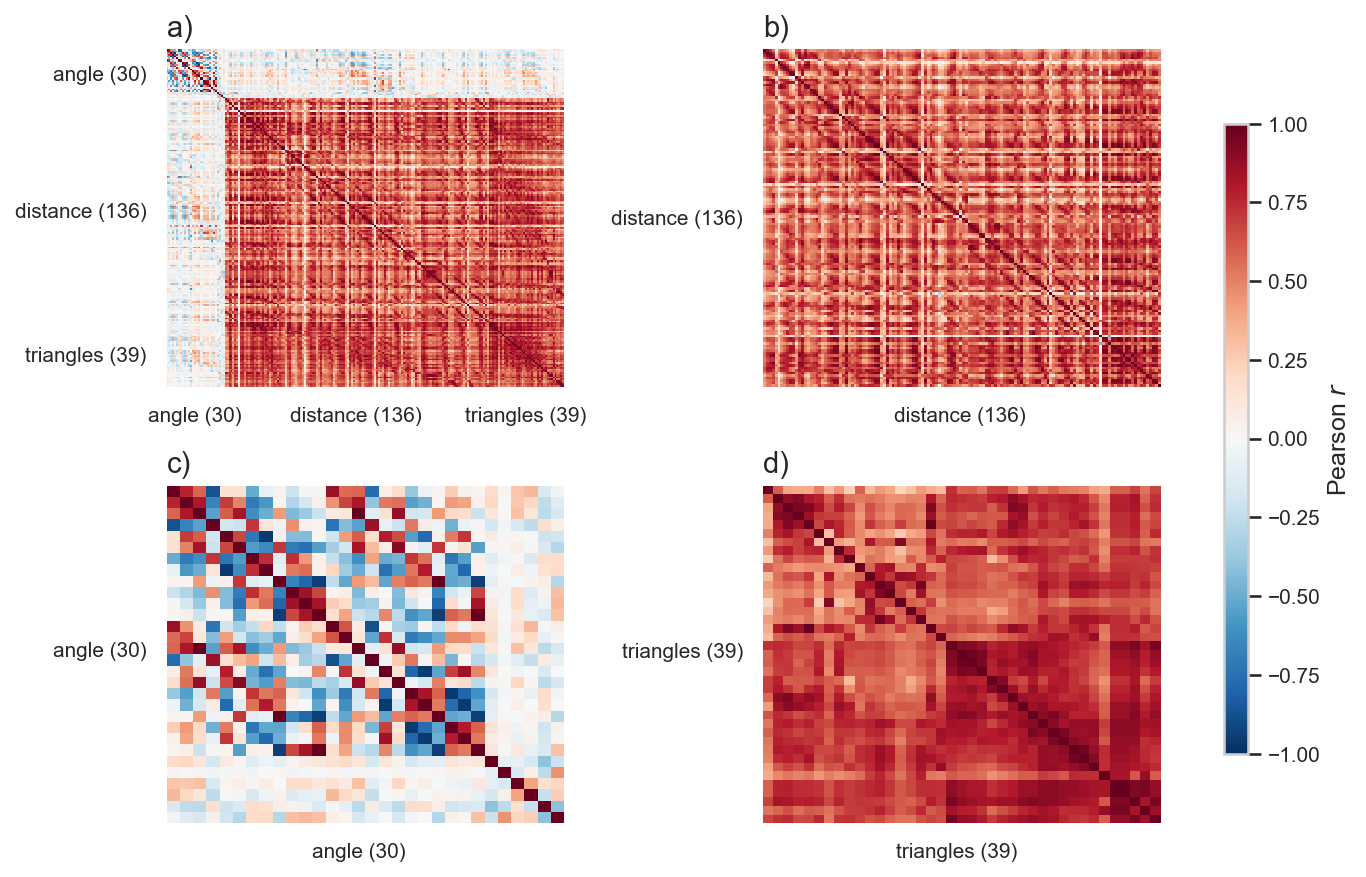

**a) Correlation Heatmap Panel**

[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.


**b) Boxplots of Top 4 Sex-Discriminative Features**

**a) Train Set**

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\Visualisations\plots_utils.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\Visualisations\plots_utils.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\Visualisations\plots_utils.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


[CAPTION] Boxplots of features ['dist10_14', 'dist3_10', 'dist9_14', 'dist3_9'] by sex (Female, Male).


C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\Visualisations\plots_utils.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


**b) Test Set**

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\Visualisations\plots_utils.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\Visualisations\plots_utils.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\Visualisations\plots_utils.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_

[CAPTION] Boxplots of features ['dist10_14', 'dist3_10', 'dist9_14', 'dist3_9'] by sex (Female, Male).


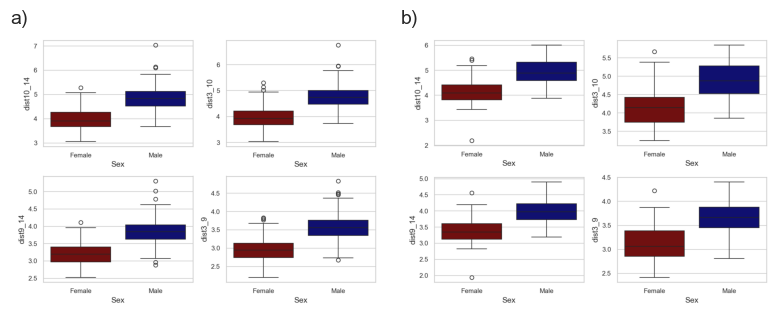

**c) UMAP Projections**

c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


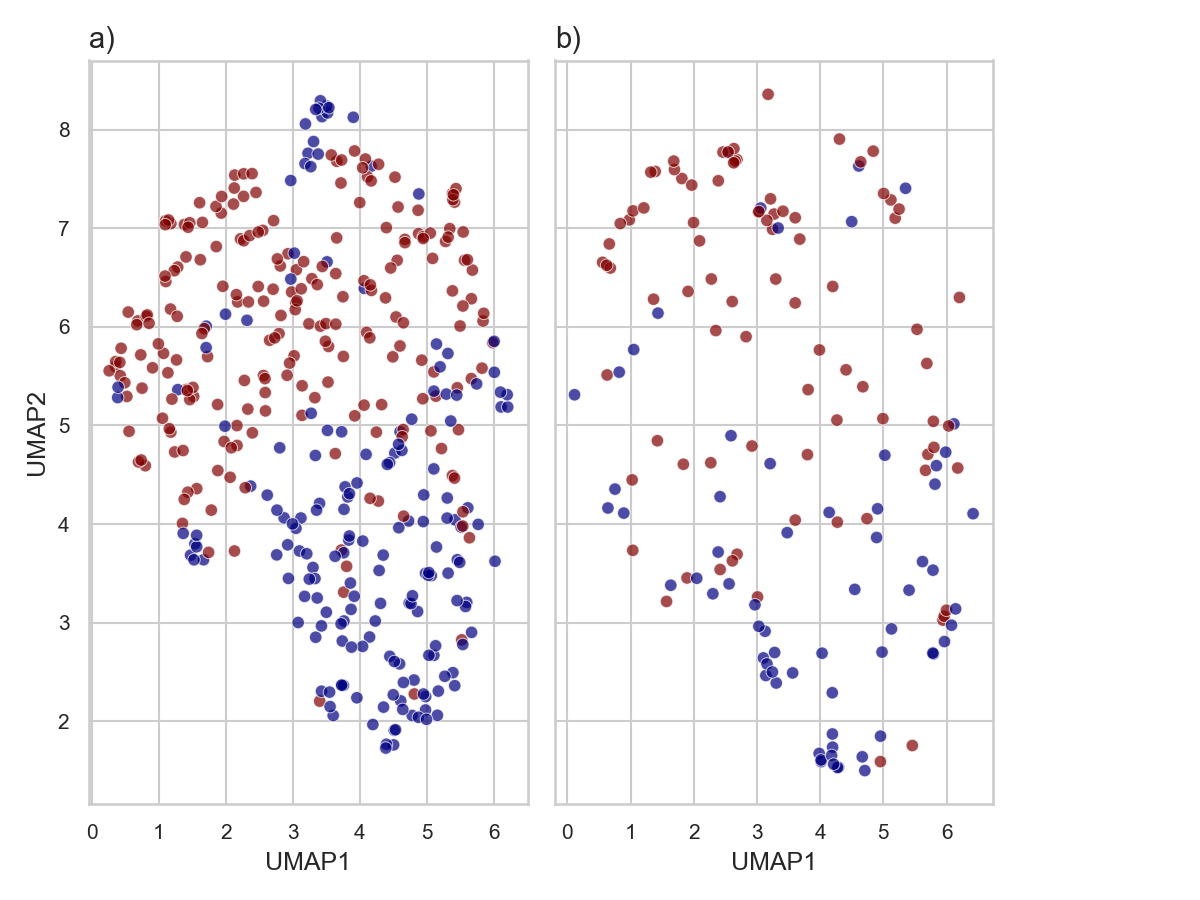

In [1]:
# Notebook: High-Level Plot Wrapper Calls with Inline Display and Combined UMAP

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

from FIT_python.config import SPLITS_DIR, RESULTS_DATA_DIR
from FIT_python.Visualisations.plot_style import apply_style, map_sex, SEX_COLORS
from FIT_python.Visualisations.plots_utils import (
    plot_feature_correlation_matrix,
    plot_sex_boxplots,
    plot_umap_scatter
)
from FIT_python.general_pipeline_steps.feature_selection_wrapper import FeatureSelectionTransformer
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# 0) Apply global style & prepare figure directory
apply_style()
fig_dir = Path(RESULTS_DATA_DIR) / "eurasian_otter_fig"
fig_dir.mkdir(exist_ok=True, parents=True)

# 1) Load & preprocess splits
split_dir = Path(SPLITS_DIR) / "eurasian_otter"
train_df = pd.read_parquet(split_dir / "train.parquet")
test_df  = pd.read_parquet(split_dir / "test.parquet")
for df in (train_df, test_df):
    df["sex_mapped"] = map_sex(df["sex"])

# 2) Correlation heatmap panel
display(Markdown("**a) Correlation Heatmap Panel**"))
corr_path = plot_feature_correlation_matrix(train_df, fig_dir)
display(Image(filename=str(corr_path)))

# 3) Select top-4 sex-discriminative features
meta_cols = ["id","species","individual_id","date","location","dataorigin","substrate","sex","trail","Fold"]
feature_cols = [c for c in train_df.columns if c not in meta_cols + ["sex_mapped"]]
selector = FeatureSelectionTransformer(method="univariate", k=4)
selector.fit(train_df[feature_cols], train_df["sex_mapped"].map({"Female":0, "Male":1}))
top4 = selector.selected_features_

# Notebook: High-Level Plot Wrapper Calls with Inline Display and Combined UMAP

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

from FIT_python.config import SPLITS_DIR, RESULTS_DATA_DIR
from FIT_python.Visualisations.plot_style import apply_style, map_sex
from FIT_python.Visualisations.plots_utils import (
    plot_feature_correlation_matrix,
    plot_sex_boxplots,
    plot_umap_scatter
)
from FIT_python.general_pipeline_steps.feature_selection_wrapper import FeatureSelectionTransformer
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer

# 0) Apply global style & prepare figure directory
apply_style()
fig_dir = Path(RESULTS_DATA_DIR) / "eurasian_otter_fig"
fig_dir.mkdir(exist_ok=True, parents=True)

# 1) Load & preprocess splits
split_dir = Path(SPLITS_DIR) / "eurasian_otter"
train_df = pd.read_parquet(split_dir / "train.parquet")
test_df  = pd.read_parquet(split_dir / "test.parquet")
for df in (train_df, test_df):
    df["sex_mapped"] = map_sex(df["sex"])

# 2) Correlation heatmap panel
display(Markdown("**a) Correlation Heatmap Panel**"))
corr_path = plot_feature_correlation_matrix(train_df, fig_dir)
#display(Image(filename=str(corr_path)))

# 3) Select top-4 sex-discriminative features
meta_cols = ["id","species","individual_id","date","location","dataorigin","substrate","sex","trail","Fold"]
feature_cols = [c for c in train_df.columns if c not in meta_cols + ["sex_mapped"]]
selector = FeatureSelectionTransformer(method="univariate", k=4)
selector.fit(train_df[feature_cols], train_df["sex_mapped"].map({"Female":0, "Male":1}))
top4 = selector.selected_features_

# 4) Boxplots of Top 4 Sex-Discriminative Features – Train vs. Test
from IPython.display import display, Markdown, Image

display(Markdown("**b) Boxplots of Top 4 Sex-Discriminative Features**"))

# only one header per 2×2 block: a) Train, b) Test
train_plot = train_df[train_df["sex_mapped"].isin(["Female","Male"])]
test_plot  = test_df [test_df ["sex_mapped"].isin(["Female","Male"])]

# Train block
display(Markdown("**a) Train Set**"))
train_box_path = plot_sex_boxplots(
    train_df, top4, fig_dir,
    filename="boxplots_train_top4.png"
)
#display(Image(filename=str(train_box_path)))

# Test block
display(Markdown("**b) Test Set**"))
test_box_path = plot_sex_boxplots(
    test_df, top4, fig_dir,
    filename="boxplots_test_top4.png"
)
#display(Image(filename=str(test_box_path)))

# Display the saved Train/Test boxplot PNGs side by side in a 1×2 figure
import matplotlib.pyplot as plt

# load the two images
train_img = plt.imread(fig_dir / "boxplots_train_top4.png")
test_img  = plt.imread(fig_dir / "boxplots_test_top4.png")

fig, axes = plt.subplots(1, 2, figsize=plt.rcParams['figure.figsize'])
# a) Train Set
axes[0].imshow(train_img)
axes[0].axis("off")
axes[0].set_title("a)", loc="left")

# b) Test Set
axes[1].imshow(test_img)
axes[1].axis("off")
axes[1].set_title("b)", loc="left")

plt.tight_layout()
plt.show()





# 5) Combined UMAP projections
display(Markdown("**c) UMAP Projections**"))

# Compute embeddings (fit on train, transform both)
reducer = DimensionalityReducerTransformer(method="umap", n_components=2)
emb_train = reducer.fit_transform(train_df[feature_cols])
emb_test  = reducer.transform(test_df[feature_cols])
emb_train_df = pd.DataFrame(emb_train, columns=["UMAP1","UMAP2"])
emb_train_df["sex_mapped"] = train_df["sex_mapped"]
emb_test_df  = pd.DataFrame(emb_test, columns=["UMAP1","UMAP2"])
emb_test_df["sex_mapped"] = test_df["sex_mapped"]

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=plt.rcParams['figure.figsize'], sharey=True)
for ax, emb_df, title in zip(
    axes,
    (emb_train_df, emb_test_df),
    ("a)", "b)")
):
    sns.scatterplot(
        data=emb_df, x="UMAP1", y="UMAP2",
        hue="sex_mapped",
        palette={"Female": SEX_COLORS["Female"], "Male": SEX_COLORS["Male"]},
        hue_order=["Female", "Male"],
        alpha=0.7,
        ax=ax,
        legend=False
    )
    ax.set_title(title, loc="left")
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

# Global legend outside
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="Sex",
           loc="center right", bbox_to_anchor=(1.15, 0.5))
fig.tight_layout(rect=[0, 0, 0.85, 1])

# Save and display
umap_path = fig_dir / "umap_combined.png"
fig.savefig(umap_path, dpi=150)
plt.close(fig)
display(Image(filename=str(umap_path)))


In [ ]:
# 6) Visualisations grouped by individual_id (analogous to sex)
from sklearn.preprocessing import LabelEncoder

display(Markdown("**d) Individual ID Visualisations**"))

# a) Counts per individual
individual_counts = train_df['individual_id'].value_counts().sort_values(ascending=False)
individual_counts.head()

# b) Select top-4 individual-discriminative features
le = LabelEncoder()
train_labels = le.fit_transform(train_df['individual_id'])
selector_ind = FeatureSelectionTransformer(method='univariate', k=4)
selector_ind.fit(train_df[feature_cols], train_labels)
top4_ind = selector_ind.selected_features_

display(Markdown("**e) Boxplots of Top 4 Individual-Discriminative Features**"))

# Train set boxplots
display(Markdown("**a) Train Set**"))
fig, axes = plt.subplots(2, 2, figsize=plt.rcParams['figure.figsize'])
for ax, feat in zip(axes.flat, top4_ind):
    sns.boxplot(data=train_df, x='individual_id', y=feat, ax=ax)
    ax.set_xlabel('Individual ID')
    ax.set_ylabel(feat)
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
train_ind_box_path = fig_dir / 'boxplots_train_individual_top4.png'
fig.savefig(train_ind_box_path, dpi=150)
plt.close(fig)

# Test set boxplots
display(Markdown("**b) Test Set**"))
fig, axes = plt.subplots(2, 2, figsize=plt.rcParams['figure.figsize'])
for ax, feat in zip(axes.flat, top4_ind):
    sns.boxplot(data=test_df, x='individual_id', y=feat, ax=ax)
    ax.set_xlabel('Individual ID')
    ax.set_ylabel(feat)
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
test_ind_box_path = fig_dir / 'boxplots_test_individual_top4.png'
fig.savefig(test_ind_box_path, dpi=150)
plt.close(fig)

# Display saved boxplots side by side
fig, axes = plt.subplots(1, 2, figsize=plt.rcParams['figure.figsize'])
axes[0].imshow(plt.imread(train_ind_box_path))
axes[0].axis('off')
axes[0].set_title('a)', loc='left')
axes[1].imshow(plt.imread(test_ind_box_path))
axes[1].axis('off')
axes[1].set_title('b)', loc='left')
plt.tight_layout()
plt.show()

# f) UMAP projections colored by individual
display(Markdown("**f) UMAP Projections by Individual**"))
reducer_ind = DimensionalityReducerTransformer(method='umap', n_components=2)
emb_train_ind = reducer_ind.fit_transform(train_df[feature_cols])
emb_test_ind = reducer_ind.transform(test_df[feature_cols])
emb_train_ind_df = pd.DataFrame(emb_train_ind, columns=['UMAP1','UMAP2'])
emb_train_ind_df['individual_id'] = train_df['individual_id']
emb_test_ind_df = pd.DataFrame(emb_test_ind, columns=['UMAP1','UMAP2'])
emb_test_ind_df['individual_id'] = test_df['individual_id']

fig, axes = plt.subplots(1, 2, figsize=plt.rcParams['figure.figsize'], sharey=True)
palette = sns.color_palette('tab20', n_colors=train_df['individual_id'].nunique())
for ax, emb_df, title in zip(axes, (emb_train_ind_df, emb_test_ind_df), ('a)', 'b)')):
    sns.scatterplot(data=emb_df, x='UMAP1', y='UMAP2', hue='individual_id', palette=palette, legend=False, alpha=0.7, ax=ax)
    ax.set_title(title, loc='left')
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title='Individual', loc='center right', bbox_to_anchor=(1.15,0.5))
fig.tight_layout(rect=[0,0,0.85,1])
umap_ind_path = fig_dir / 'umap_individual_combined.png'
fig.savefig(umap_ind_path, dpi=150)
plt.close(fig)
display(Image(filename=str(umap_ind_path)))
